# Data exploration
Data exploratin of the final dataset: 
- day, pos, number of vessel, bgc variables 

# Set

In [38]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
YEAR = 2024

raw = "../data/raw/"
interim_folder = "../data/interim/"
processed_folder = "../data/processed/"

cpr_gfw_dp_name = f"cpr_gfw_{YEAR}.parquet"
ais_dp_name = f"cleaned_ais_high_daily_ts_{YEAR}.parquet"
s2_dp_name = f"cleaned_s2_vessel_detections_{YEAR}.parquet"
gulf_coords_dp_name = "ts_gulf_coords.csv"

# Import 

In [9]:
cpr_gfw = pd.read_parquet(f"{processed_folder}{cpr_gfw_dp_name}")
ais = pd.read_parquet(f"{interim_folder}{ais_dp_name}")
sar = pd.read_parquet(f"{interim_folder}{s2_dp_name}")

gulf_coords = pd.read_csv(f"{raw}{gulf_coords_dp_name}")

# Trawlers vs other - spatial analysis 

In [10]:
sar_unq_coords = sar[['latitude', 'longitude']].drop_duplicates()
ais_unq_coords = ais[['latitude', 'longitude']].drop_duplicates()

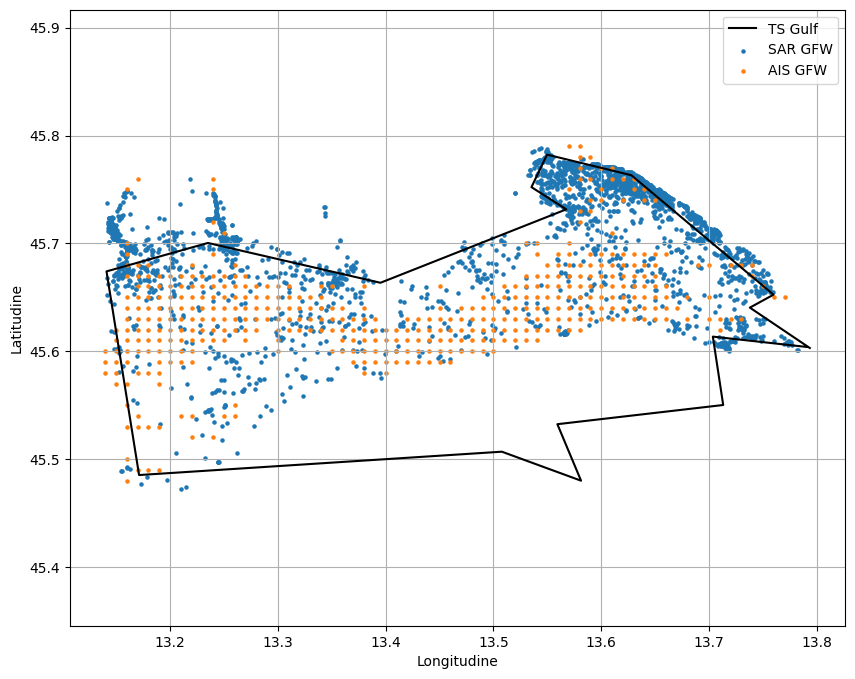

In [11]:
plt.figure(figsize=(10,8))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(sar_unq_coords['longitude'], sar_unq_coords['latitude'], label = 'SAR GFW', s = 5)
plt.scatter(ais_unq_coords['longitude'], ais_unq_coords['latitude'], label = 'AIS GFW', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [25]:
trawlers_condition = ais['gear_type'] == 'TRAWLERS'
pots_and_traps_condition = ais['gear_type'] == 'POTS_AND_TRAPS'
dredge_fishing_condition = ais['gear_type'] == 'DREDGE_FISHING'
other_purse_seines_condition = ais['gear_type'] == 'OTHER_PURSE_SEINES'
fishing_condition = ais['gear_type'] == 'FISHING'   

ais_trawlers = ais[trawlers_condition].copy()
ais_n_trawlers = ais[~trawlers_condition].copy()
ais_pots_and_traps = ais[pots_and_traps_condition].copy()
ais_dredge_fishing = ais[dredge_fishing_condition].copy()
ais_other_purse_seines = ais[other_purse_seines_condition].copy()
ais_fishing = ais[fishing_condition].copy()


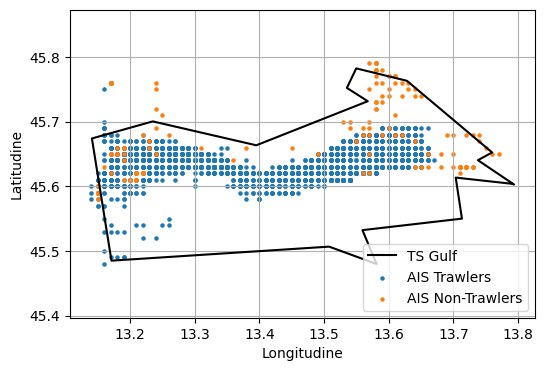

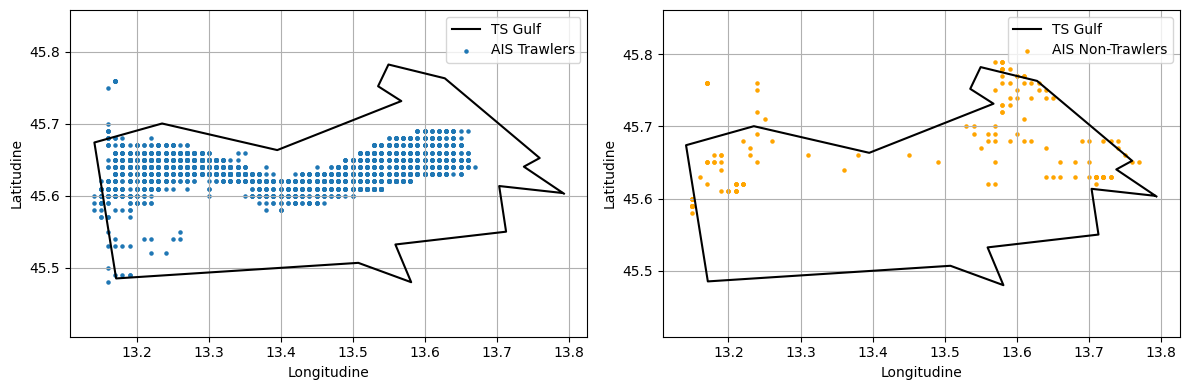

In [26]:
plt.figure(figsize=(6,4))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], label = 'AIS Non-Trawlers', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Primo subplot: Trawlers ---
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()

# --- Secondo subplot: Non-Trawlers ---
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], s=5, color='orange', label='AIS Non-Trawlers')
axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


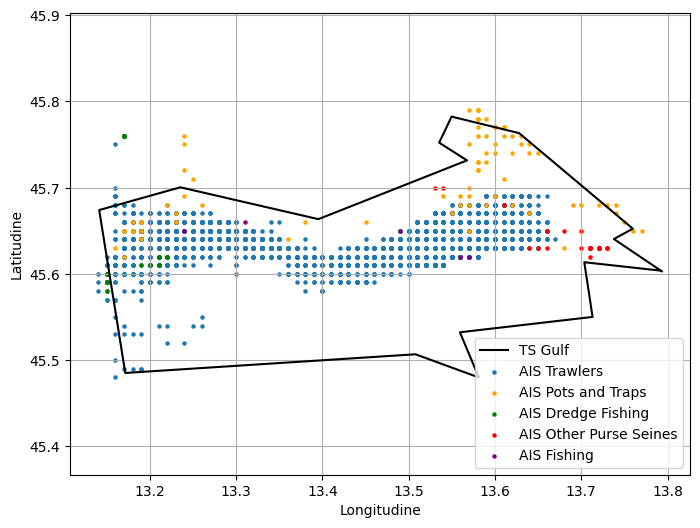

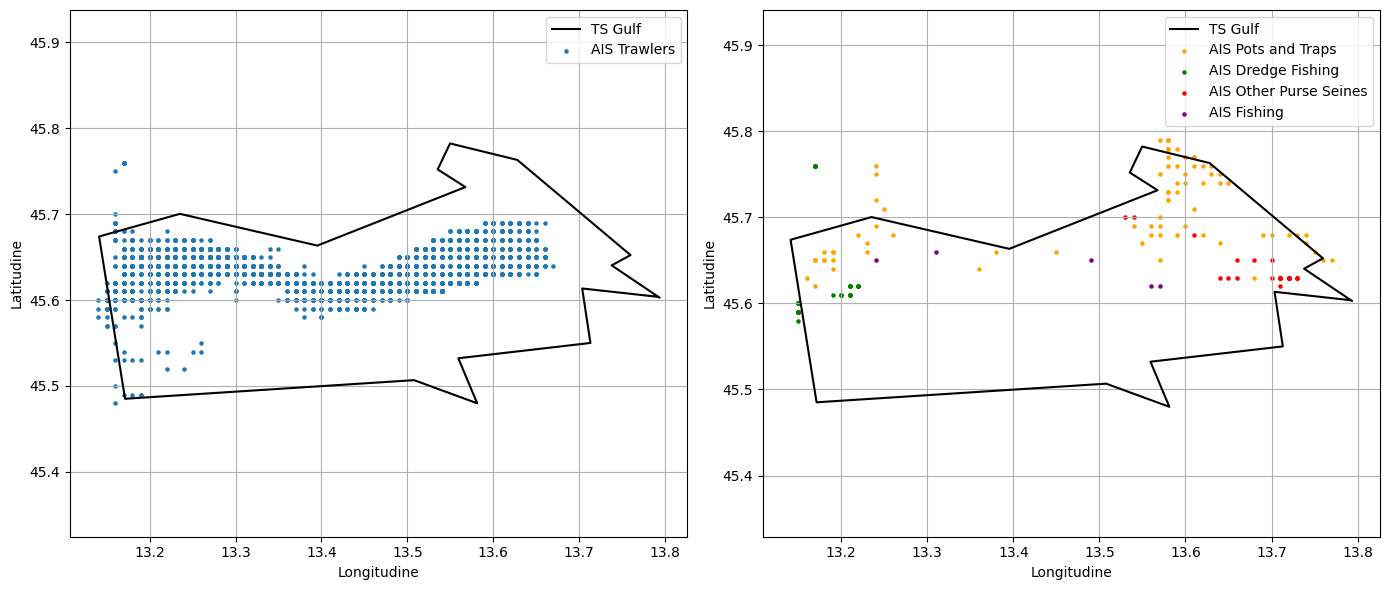

In [33]:
plt.figure(figsize=(8,6))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], label = 'AIS Pots and Traps', s = 5, color = 'orange')
plt.scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], label = 'AIS Dredge Fishing', s = 5, color = 'green')
plt.scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], label = 'AIS Other Purse Seines', s = 5, color = 'red')
plt.scatter(ais_fishing['longitude'], ais_fishing['latitude'], label = 'AIS Fishing', s = 5, color = 'purple')
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')

axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')

axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()


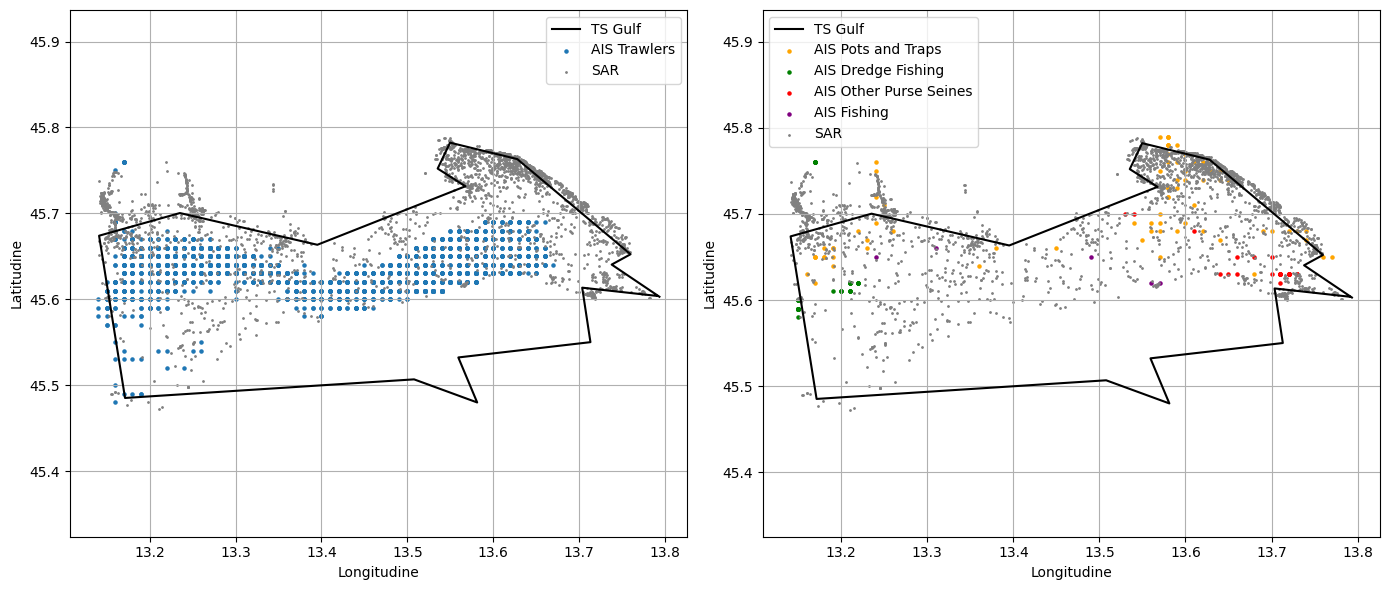

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')
axes[1].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()

# Marine variables - spatial analysis 

In [37]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,45.479168,13.166667,0.432612,13.304394,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,False,None,False,45.479168,13.166667,0.409951,13.248711,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,False,None,False,45.479168,13.166667,0.387921,13.063446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,False,None,False,45.479168,13.166667,0.367288,12.772483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,False,None,False,45.479168,13.166667,0.347252,13.004619,0.0,0.0,0.0,0.0,0.0,0.0,0.0


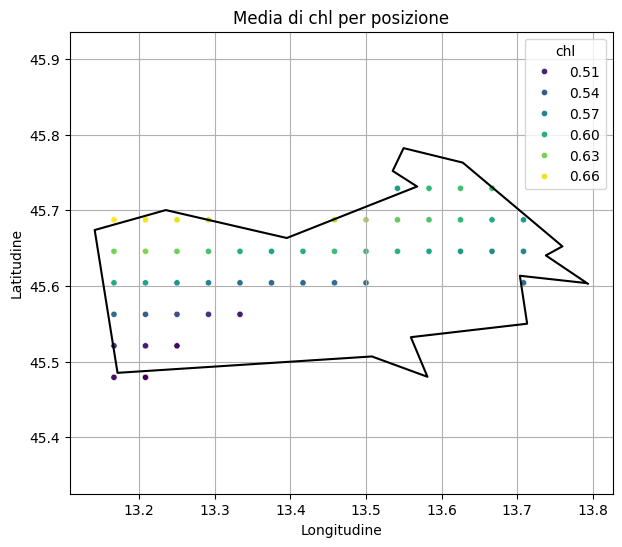

In [51]:
bgc_var_name = "chl" # chl, thetao

df_pos = cpr_gfw.groupby(["latitude", "longitude"], as_index=False)[bgc_var_name].mean()


plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=df_pos,
    x="longitude",
    y="latitude",
    hue=bgc_var_name,
    palette="viridis",
    s=20
)
plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], color = 'black')

plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title(f"Media di {bgc_var_name} per posizione")
plt.axis("equal")
plt.grid(True)

plt.show()
